In [88]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

In [89]:
with rasterio.open(r"C:\Users\febin\Downloads\Bodensee.tiff") as src:
    bodensee_img=src.read()
    profile=src.profile


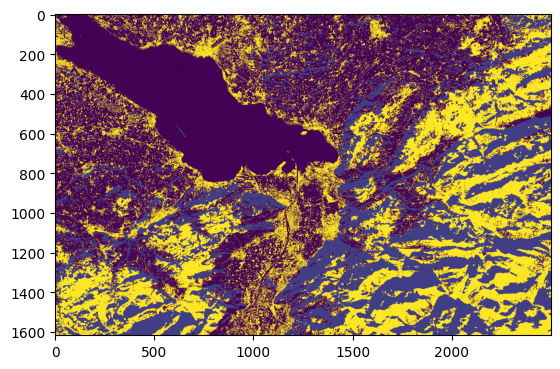

In [90]:
with rasterio.open(r"C:\Users\febin\Downloads\Bodensee_classification.tiff") as src:
    bodensee_class=src.read(1)
plt.imshow(bodensee_class)

In [91]:
# Reshape image
bands, height, width = bodensee_img.shape

X = bodensee_img.reshape(bands, -1).T  # features
y = bodensee_class.reshape(-1)         # labels

In [92]:
mask = y != 0  
X = X[mask]
y = y[mask]

In [93]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [94]:
with rasterio.open(r"C:\Users\febin\Downloads\Walchensee.tiff") as  src:
    walchensee_img=src.read()
    

In [95]:
bands, height, width = walchensee_img.shape

X_walchensee = walchensee_img.reshape(bands, -1).T
print(X_walchensee)

[[114 103  69]
 [136 122 106]
 [139 108  85]
 ...
 [  0  10   0]
 [  0  15   3]
 [  0   7   4]]


In [96]:
predictions = rf.predict(X_walchensee)

In [97]:
classified = predictions.reshape(height, width)

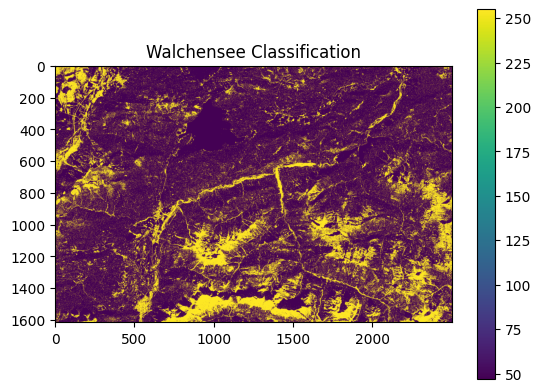

In [98]:


plt.imshow(classified)
plt.colorbar()
plt.title(
    "Walchensee Classification")
plt.show()